Barton Block R11833485

Project 1

CS 4331-102

In [21]:
!pip install gensim

In [34]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from gensim.models import Word2Vec
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
nltk.download('stopwords')
nltk.download('wordnet')
import joblib
import time
from sklearn.metrics import precision_score, recall_score, f1_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [23]:
# import training data

data = "/content/train_data with labels.xlsx"
df = pd.read_excel(data)

In [24]:
df.head()

,text,label
0,Councils are debating if building housing area...,0
1,While reading the succesful people's lifes you...,0
2,"Finally, she felt that the robotics unit was i...",1
3,Since sigmoid can be viewed as a special 2clas...,1
4,In this essay we will talk about why in so man...,0


In [25]:
print("\nClass Distribution:")
df['label'].value_counts()


Class Distribution:


,count
label,
0,4088
1,4088


In [26]:
print("\nClass Distribution:")
df['label'].value_counts()


Class Distribution:


,count
label,
0,4088
1,4088


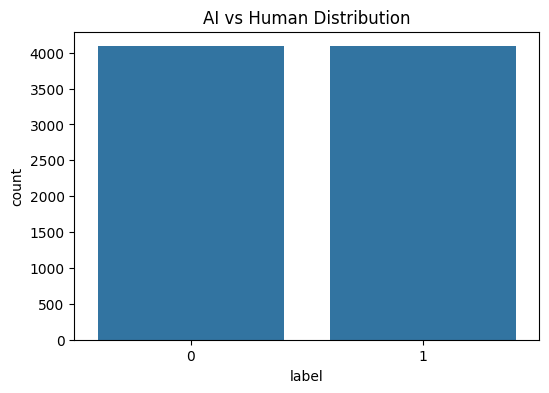

In [27]:
# exploratory data analysis

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("AI vs Human Distribution")
plt.show()

In [28]:
# text preprocessing

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df["clean_text"] = df["text"].apply(preprocess_text)

df.head()

,text,label,clean_text
0,Councils are debating if building housing area...,0,council debating building housing area expande...
1,While reading the succesful people's lifes you...,0,reading succesful people life probably see one...
2,"Finally, she felt that the robotics unit was i...",1,finally felt robotics unit important engage st...
3,Since sigmoid can be viewed as a special 2clas...,1,since sigmoid viewed special 2class case e 0 c...
4,In this essay we will talk about why in so man...,0,essay talk many country student prefer choose ...


In [29]:
# split text and labels

X = df["text"]
y = df["label"]
# 0 = human, 1 = AI

In [30]:
# split dataset into train set and test set

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)

# feature engineering

In [31]:
# feature engineering using TF-IDF

tfidf = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b",
    lowercase=True,
    stop_words="english",
    max_features=15000,
    min_df=2,
    max_df=0.95
    )

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(6540, 15000)


In [32]:
sentences = [text.split() for text in df["clean_text"]]

w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
    )

# model development
## ML models

In [35]:
# ML model 1 - SVM

svm_params = {
    'C':[0.1,1,10]
}

svm_grid = GridSearchCV(
    LinearSVC(),
    svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm_grid.fit(X_train_tfidf, y_train)

print(svm_grid.best_params_)
print(svm_grid.best_score_)

{'C': 1}
0.967737003058104


In [51]:
# ML model 2 - Decision Tree

tree_params = {
    'max_depth':[5,10,20,None],
    'min_samples_split':[2,5,10]
}

tree_grid = GridSearchCV(
    DecisionTreeClassifier(),
    tree_params,
    cv=5,
    scoring='accuracy'
)

tree_grid.fit(X_train_tfidf, y_train)

print(tree_grid.best_params_)

{'max_depth': 20, 'min_samples_split': 5}


In [53]:
# ML model 3 - AdaBoost

ada_params = {
    'n_estimators':[50,100],
    'learning_rate':[0.1,1]
    }

ada_grid = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    ada_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
    )

ada_grid.fit( X_train_tfidf, y_train )

print(ada_grid.best_params_)

{'learning_rate': 1, 'n_estimators': 100}


## tokenization for LTSM & CNN

In [43]:
MAX_WORDS = 20000
MAX_LEN = 300

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN)

vocab_size = min(MAX_WORDS, len(tokenizer.word_index)+1)

## DL models

In [44]:
# DL model 1 - FNN

fnn = Sequential([
    Dense(
        128,
        activation='relu',
        input_shape=(X_train_tfidf.shape[1],)
    ),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

fnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

fnn.fit(
    X_train_tfidf.toarray(),
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8513 - loss: 0.3994 - val_accuracy: 0.9618 - val_loss: 0.1080
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9885 - loss: 0.0397 - val_accuracy: 0.9664 - val_loss: 0.0889
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9996 - loss: 0.0068 - val_accuracy: 0.9687 - val_loss: 0.0927
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9998 - loss: 0.0024 - val_accuracy: 0.9709 - val_loss: 0.0978
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9694 - val_loss: 0.0991
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 1.0000 - loss: 8.4560e-04 - val_accuracy: 0.9702 - val_loss: 0.1026
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 1.0000 - loss: 5.9998e-04 - val_accuracy: 0.9709 - val_loss: 0.1076
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9998 - loss: 8.0175e-04 - val_accuracy

In [45]:
# DL model 2 - LSTM

lstm_model = Sequential([
    Embedding(
        vocab_size,
        128,
        input_length=MAX_LEN
    ),
    LSTM(128),
    Dropout(0.3),
    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


82/82 ━━━━━━━━━━━━━━━━━━━━ 73s 862ms/step - accuracy: 0.6554 - loss: 0.6211 - val_accuracy: 0.7936 - val_loss: 0.4815
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 71s 863ms/step - accuracy: 0.9232 - loss: 0.2268 - val_accuracy: 0.9350 - val_loss: 0.1926
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 81s 843ms/step - accuracy: 0.9788 - loss: 0.0755 - val_accuracy: 0.9465 - val_loss: 0.1876
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 68s 836ms/step - accuracy: 0.9874 - loss: 0.0470 - val_accuracy: 0.8945 - val_loss: 0.3295
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 848ms/step - accuracy: 0.9235 - loss: 0.1842 - val_accuracy: 0.9151 - val_loss: 0.2885
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 843ms/step - accuracy: 0.9803 - loss: 0.0705 - val_accuracy: 0.8838 - val_loss: 0.3390
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 70s 856ms/step - accuracy: 0.9908 - loss: 0.0338 - val_accuracy: 0.8907 - val_loss: 0.3762
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 71s 861ms/step - accuracy: 0.9945 - loss: 0.0240 - val_accuracy: 0.906

In [46]:
# DL model 3 - CNN for Text

cnn_model = Sequential([
    Embedding(
        vocab_size,
        128,
        input_length=MAX_LEN
    ),
    Conv1D(
        128,
        5,
        activation='relu'
    ),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 28s 318ms/step - accuracy: 0.7080 - loss: 0.5619 - val_accuracy: 0.8731 - val_loss: 0.3109
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 319ms/step - accuracy: 0.9207 - loss: 0.1977 - val_accuracy: 0.9381 - val_loss: 0.1468
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 329ms/step - accuracy: 0.9794 - loss: 0.0664 - val_accuracy: 0.9526 - val_loss: 0.1236
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 312ms/step - accuracy: 0.9956 - loss: 0.0196 - val_accuracy: 0.9549 - val_loss: 0.1202
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 328ms/step - accuracy: 0.9985 - loss: 0.0095 - val_accuracy: 0.9526 - val_loss: 0.1311
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 314ms/step - accuracy: 0.9990 - loss: 0.0050 - val_accuracy: 0.9549 - val_loss: 0.1348
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 312ms/step - accuracy: 0.9994 - loss: 0.0043 - val_accuracy: 0.9526 - val_loss: 0.1487
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 326ms/step - accuracy: 0.9990 - loss: 0.0041 - val_accu

# evaluation & comparison
## evaluate models

In [47]:
# evaluation function

def evaluate_model(model, X_test, y_test, name):

    predictions = model.predict(X_test)

    if len(predictions.shape) > 1:
        predictions = (predictions > 0.5).astype(int)

    print("\n")
    print("="*50)
    print(name)
    print("="*50)

    print(classification_report(y_test, predictions))

    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()



SVM
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       811
           1       0.97      0.97      0.97       825

    accuracy                           0.97      1636
   macro avg       0.97      0.97      0.97      1636
weighted avg       0.97      0.97      0.97      1636



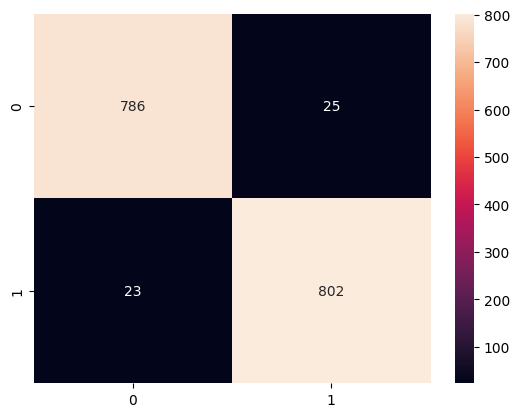



Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       811
           1       0.89      0.91      0.90       825

    accuracy                           0.89      1636
   macro avg       0.89      0.89      0.89      1636
weighted avg       0.89      0.89      0.89      1636



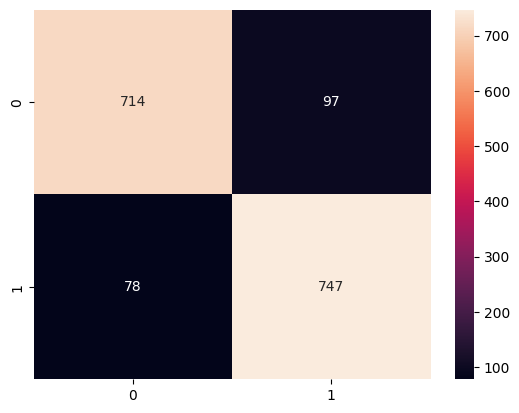



AdaBoost
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       811
           1       0.93      0.95      0.94       825

    accuracy                           0.94      1636
   macro avg       0.94      0.94      0.94      1636
weighted avg       0.94      0.94      0.94      1636



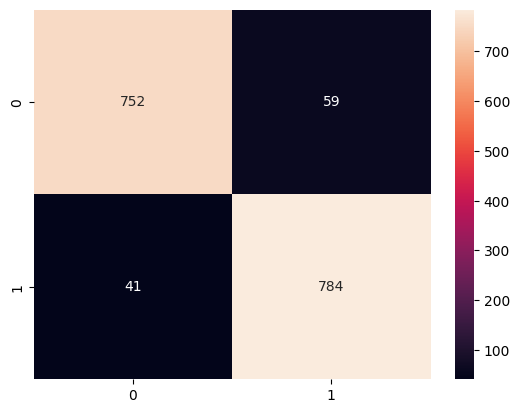

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


FNN
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       811
           1       0.98      0.97      0.97       825

    accuracy                           0.97      1636
   macro avg       0.97      0.97      0.97      1636
weighted avg       0.97      0.97      0.97      1636



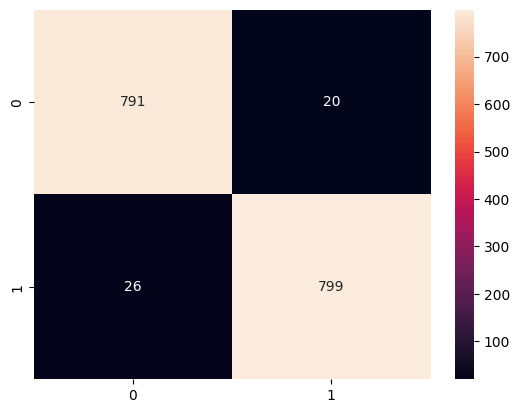

52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step


LSTM
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       811
           1       0.93      0.86      0.89       825

    accuracy                           0.90      1636
   macro avg       0.90      0.90      0.90      1636
weighted avg       0.90      0.90      0.90      1636



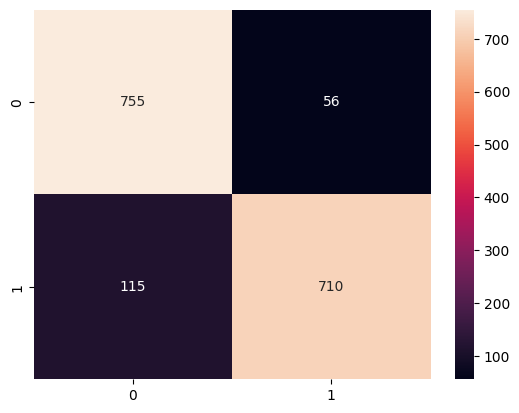

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step


CNN
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       811
           1       0.97      0.95      0.96       825

    accuracy                           0.96      1636
   macro avg       0.96      0.96      0.96      1636
weighted avg       0.96      0.96      0.96      1636



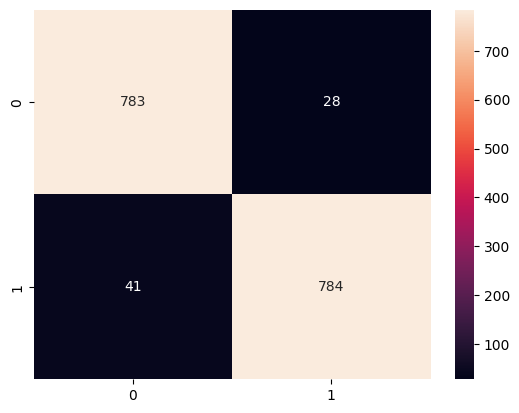

In [54]:
# evaluate all models

evaluate_model(
    svm_grid.best_estimator_,
    X_test_tfidf,
    y_test,
    "SVM"
)

evaluate_model(
    tree_grid.best_estimator_,
    X_test_tfidf,
    y_test,
    "Decision Tree"
)

evaluate_model(
    ada_grid.best_estimator_,
    X_test_tfidf,
    y_test,
    "AdaBoost"
)

evaluate_model(
    fnn,
    X_test_tfidf.toarray(),
    y_test,
    "FNN"
)

evaluate_model(
    lstm_model,
    X_test_pad,
    y_test,
    "LSTM"
)

evaluate_model(
    cnn_model,
    X_test_pad,
    y_test,
    "CNN"
)

In [55]:
# save models for app

joblib.dump(
    svm_grid.best_estimator_,
    "svm_model.pkl"
)

joblib.dump(
    tree_grid.best_estimator_,
    "decision_tree_model.pkl"
)

joblib.dump(
    ada_grid.best_estimator_,
    "adaboost_model.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

fnn.save("fnn_model.h5")
lstm_model.save("lstm_model.h5")
cnn_model.save("cnn_model.h5")

## compare models


In [56]:
# collect metrics

results = []

In [58]:
# SVM

start = time.time()

svm_pred = svm_grid.best_estimator_.predict(X_test_tfidf)

elapsed = time.time() - start

results.append({
    "Model":"SVM",
    "Type":"ML",
    "Features":"TF-IDF",
    "Accuracy":accuracy_score(y_test, svm_pred),
    "Precision":precision_score(y_test, svm_pred),
    "Recall":recall_score(y_test, svm_pred),
    "F1":f1_score(y_test, svm_pred),
    "Prediction Time (s)":elapsed
})

In [59]:
# decision tree

start = time.time()

tree_pred = tree_grid.best_estimator_.predict(X_test_tfidf)

elapsed = time.time() - start

results.append({
    "Model":"Decision Tree",
    "Type":"ML",
    "Features":"TF-IDF",
    "Accuracy":accuracy_score(y_test, tree_pred),
    "Precision":precision_score(y_test, tree_pred),
    "Recall":recall_score(y_test, tree_pred),
    "F1":f1_score(y_test, tree_pred),
    "Prediction Time (s)":elapsed
})

In [60]:
# AdaBoost

start = time.time()

ada_pred = ada_grid.best_estimator_.predict(X_test_tfidf)

elapsed = time.time() - start

results.append({
    "Model":"AdaBoost",
    "Type":"ML",
    "Features":"TF-IDF",
    "Accuracy":accuracy_score(y_test, ada_pred),
    "Precision":precision_score(y_test, ada_pred),
    "Recall":recall_score(y_test, ada_pred),
    "F1":f1_score(y_test, ada_pred),
    "Prediction Time (s)":elapsed
})

In [61]:
# FNN

start = time.time()

fnn_pred = (fnn.predict(X_test_tfidf.toarray()) > 0.5).astype(int)

elapsed = time.time() - start

results.append({
    "Model":"FNN",
    "Type":"DL",
    "Features":"TF-IDF",
    "Accuracy":accuracy_score(y_test, fnn_pred),
    "Precision":precision_score(y_test, fnn_pred),
    "Recall":recall_score(y_test, fnn_pred),
    "F1":f1_score(y_test, fnn_pred),
    "Prediction Time (s)":elapsed
})

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [62]:
# LSTM

start = time.time()

lstm_pred = (lstm_model.predict(X_test_pad) > 0.5).astype(int)

elapsed = time.time() - start

results.append({
    "Model":"LSTM",
    "Type":"DL",
    "Features":"Word Embeddings",
    "Accuracy":accuracy_score(y_test, lstm_pred),
    "Precision":precision_score(y_test, lstm_pred),
    "Recall":recall_score(y_test, lstm_pred),
    "F1":f1_score(y_test, lstm_pred),
    "Prediction Time (s)":elapsed
})

52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step


In [63]:
# CNN

start = time.time()

cnn_pred = (cnn_model.predict(X_test_pad) > 0.5).astype(int)

elapsed = time.time() - start

results.append({
    "Model":"CNN",
    "Type":"DL",
    "Features":"Word Embeddings",
    "Accuracy":accuracy_score(y_test, cnn_pred),
    "Precision":precision_score(y_test, cnn_pred),
    "Recall":recall_score(y_test, cnn_pred),
    "F1":f1_score(y_test, cnn_pred),
    "Prediction Time (s)":elapsed
})

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step


In [64]:
# display final results

results_df = pd.DataFrame(results)
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Type,Features,Accuracy,Precision,Recall,F1,Prediction Time (s)
3,FNN,DL,TF-IDF,0.971883,0.975580,0.968485,0.972019,1.171787
0,SVM,ML,TF-IDF,0.970660,0.969770,0.972121,0.970944,0.008314
5,CNN,DL,Word Embeddings,0.957824,0.965517,0.950303,0.957850,1.850251
2,AdaBoost,ML,TF-IDF,0.938875,0.930012,0.950303,0.940048,0.243168
4,LSTM,DL,Word Embeddings,0.895477,0.926893,0.860606,0.892520,7.162557
1,Decision Tree,ML,TF-IDF,0.893032,0.885071,0.905455,0.895147,0.005815


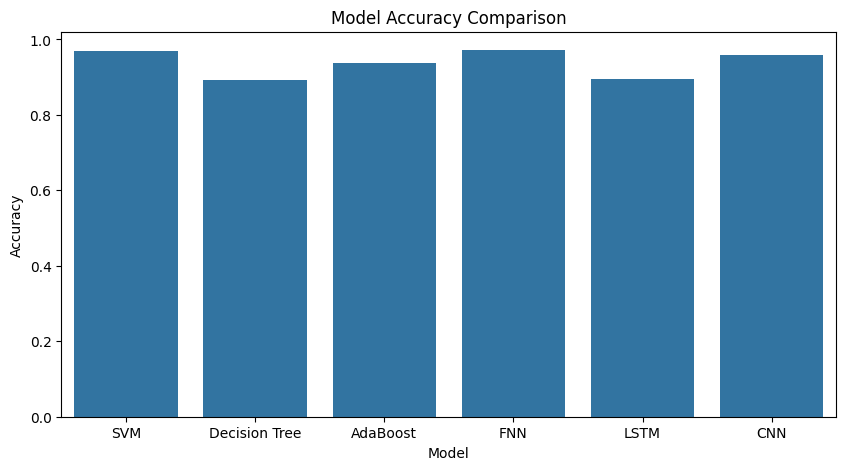

In [65]:
# accuracy comparison plot

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.show()

### ML vs DL

In [66]:
# ML vs DL

ml_accuracy = results_df[results_df["Type"] == "ML"]["Accuracy"].mean()
dl_accuracy = results_df[results_df["Type"] == "DL"]["Accuracy"].mean()

comparison = pd.DataFrame({
    "Category":["ML","DL"],
    "Average Accuracy":[
        ml_accuracy,
        dl_accuracy
    ]
})

comparison

,Category,Average Accuracy
0,ML,0.934189
1,DL,0.941728


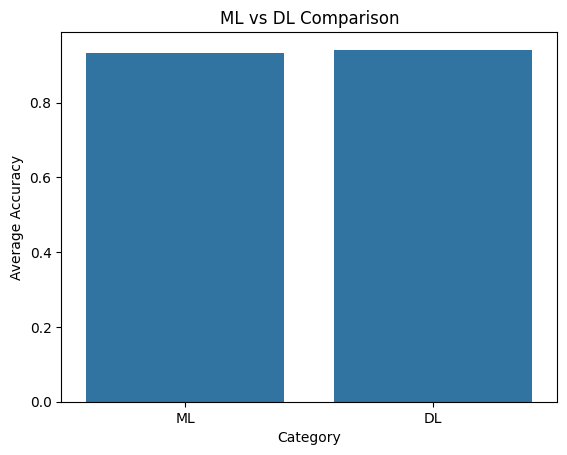

In [67]:
# visualization

sns.barplot(
    data=comparison,
    x="Category",
    y="Average Accuracy"
)

plt.title("ML vs DL Comparison")
plt.show()

### TFIDF vs Word embedding

In [68]:
feature_comparison = results_df.groupby(
    "Features")[["Accuracy","F1"]].mean()

feature_comparison

,Accuracy,F1
Features,,
TF-IDF,0.943612,0.944540
Word Embeddings,0.926650,0.925185


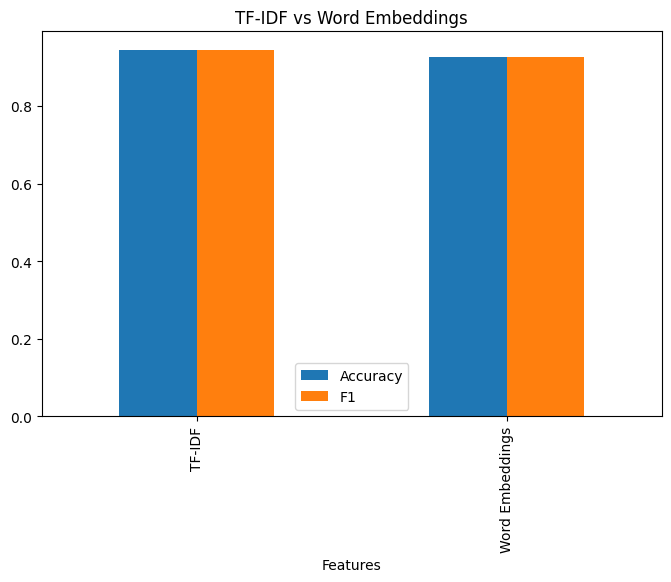

In [69]:
# visualization

feature_comparison.plot(kind="bar",figsize=(8,5))
plt.title("TF-IDF vs Word Embeddings")
plt.show()

### speed vs accuracy

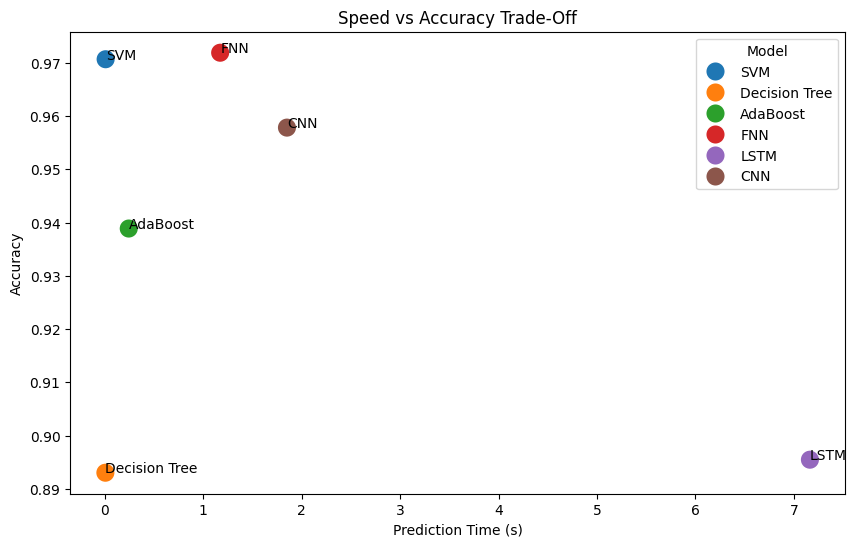

In [70]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=results_df,
    x="Prediction Time (s)",
    y="Accuracy",
    hue="Model",
    s=200
)

for _, row in results_df.iterrows():

    plt.text(
        row["Prediction Time (s)"],
        row["Accuracy"],
        row["Model"]
    )

plt.title("Speed vs Accuracy Trade-Off")

plt.show()

### ROC curves for all models

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step


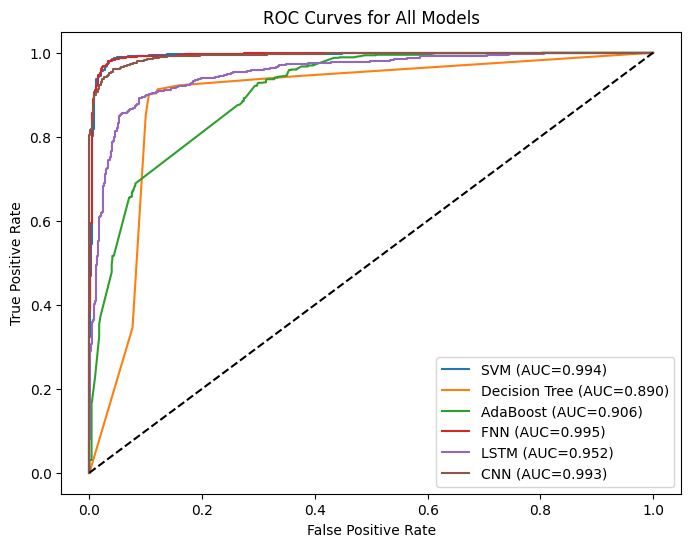

In [74]:
plt.figure(figsize=(8,6))

models = {

    "SVM":
        svm_grid.best_estimator_.decision_function(X_test_tfidf),

    "Decision Tree":
        tree_grid.best_estimator_.predict_proba(X_test_tfidf)[:,1],

    "AdaBoost":
        ada.predict_proba(X_test_tfidf)[:,1],

    "FNN":
        fnn.predict(X_test_tfidf.toarray()).ravel(),

    "LSTM":
        lstm_model.predict(X_test_pad).ravel(),

    "CNN":
        cnn_model.predict(X_test_pad).ravel()
}

for name, scores in models.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.show()

# Discussion

Which model performed best overall?



Why do you think that is?



Which features were most useful for detecting AI text?



Where did models fail? What types of text fooled them?



Would you use this tool in a real classroom setting? Why or why not?

